#**2. Data Understanding & Data Quality Assesment**

**a. Data set overview**

In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df_raw = pd.read_csv('/content/dirty_cafe_sales.csv')

# melakukan copy untuk preprocessing
df_prep = df_raw.copy()

# preview data
df_prep.head(20)



,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# melihat ukuran dataset
df_prep.shape

(10000, 8)

In [ ]:
# melihat struktur dan tipe data
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
# melihat statistiknya
df_prep.describe().T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_9226047,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


**b. Data quality issues**

In [ ]:
# melakukan cek missing values
pd.DataFrame({
    'Missing values': df_prep.isnull().sum(),
    'Missing percentage (%)': df_prep.isnull().sum() / len(df_prep)*100
})

,Missing values,Missing percentage (%)
Transaction ID,0,0.00
Item,333,3.33
Quantity,138,1.38
Price Per Unit,179,1.79
Total Spent,173,1.73
Payment Method,2579,25.79
Location,3265,32.65
Transaction Date,159,1.59


In [ ]:
# cek duplikasi

df_prep.duplicated().sum()

np.int64(0)

In [ ]:
# cek tipe data
df_prep.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
# cek nilai tidak valid, seperti error atau unknown
for col in df_prep.columns:
  print(f"\n{col}")
  print(df_prep[col].unique())


Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']

Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']

Quantity
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]

Price Per Unit
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']

Total Spent
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']

Payment Method
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

Location
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

Transaction Date
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' 

In [ ]:
# melakukan cek deskripsi data
df_prep.describe().T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_9226047,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


# **3. Data Wrangling & Preparation**

**a. Data cleaning steps**

In [ ]:
# menghapus data yang terduplikasi
df_prep = df_prep.drop_duplicates().reset_index(drop = True)

In [ ]:
# mengubah nilai yang tidak valid, seperti error/uknown, jadi NaN
df_prep = df_prep.replace(['UNKNOWN', 'ERROR'], pd.NA)

In [ ]:
# mengubah isi kolom diubah menjadi angka dan tanggal
df_prep['Quantity'] = pd.to_numeric(df_prep['Quantity'], errors = 'coerce')
df_prep['Price Per Unit'] = pd.to_numeric(df_prep['Price Per Unit'], errors = 'coerce')
df_prep['Total Spent'] = pd.to_numeric(df_prep['Total Spent'], errors = 'coerce')
df_prep['Transaction Date'] = pd.to_datetime(df_prep['Transaction Date'], errors = 'coerce')


In [ ]:
# menghitung total spent untuk mengisi kolom yang kosong saja
df_prep['Total Spent'] = df_prep['Total Spent'].fillna(df_prep['Quantity'] * df_prep['Price Per Unit'])

In [ ]:
# menghapus baris yang memiliki nilai kosong atau NaN pada dikolom yang disebutkan
df_prep = df_prep.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'Item'])

In [ ]:
# mengubah tipe data quantity menjadi lebih sesuai
df_prep['Quantity'] = df_prep['Quantity'].astype('int64')

In [ ]:
# melihat data setelah cleaning
df_prep.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,<NA>,2023-10-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31
10,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03


In [ ]:
# melihat struktur dan tipe data yang sudah di cleaning
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7773 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7773 non-null   object        
 1   Item              7773 non-null   object        
 2   Quantity          7773 non-null   int64         
 3   Price Per Unit    7773 non-null   float64       
 4   Total Spent       7773 non-null   float64       
 5   Payment Method    5319 non-null   object        
 6   Location          4679 non-null   object        
 7   Transaction Date  7773 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 546.5+ KB


**b. Handling missing values & Outliers**

In [ ]:
# mengecek jumlah missing value
pd.DataFrame({
    'Missing values': df_prep.isnull().sum(),
    'Missing percentage (%)': df_prep.isnull().sum() / len(df_prep)*100
})

,Missing values,Missing percentage (%)
Transaction ID,0,0.000000
Item,0,0.000000
Quantity,0,0.000000
Price Per Unit,0,0.000000
Total Spent,0,0.000000
Payment Method,2454,31.570822
Location,3094,39.804451
Transaction Date,0,0.000000


In [ ]:
# mengisi baris yang memiliki missing value dengan nilai yang paling sering muncul
df_prep['Payment Method'] = df_prep['Payment Method'].fillna(df_prep['Payment Method'].mode()[0])
df_prep['Location'] = df_prep['Location'].fillna(df_prep['Location'].mode()[0])

In [ ]:
# mengecek berapa persen missing value yang ada
pd.DataFrame({
    'Missing Count' : df_prep.isnull().sum(),
    'Missing Precentage' : df_prep.isnull().sum() / len(df_prep) * 100
})

,Missing Count,Missing Precentage
Transaction ID,0,0.0
Item,0,0.0
Quantity,0,0.0
Price Per Unit,0,0.0
Total Spent,0,0.0
Payment Method,0,0.0
Location,0,0.0
Transaction Date,0,0.0


In [ ]:
# melakukan penyimpanan kondisi awal sebelum mendeteksi dan menangani outliers yang ada
df_before = df_prep.copy()

print("Before:", len(df_before))

Before: 7773


In [ ]:
# memilih kolom yang berupa angka
numerical_cols =  df_prep.select_dtypes(include=['float64']).columns

# mengahapus outliers yang ada
for col in numerical_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_prep = df_prep[(df_prep[col] >= lower) & (df_prep[col] <= upper)]

df_prep = df_prep.reset_index(drop=True)

# hasil outliers yang terhapus
print("After:", len(df_prep))


After: 7562


In [ ]:
# mengecek outliers yang sudah dicleaning
df_prep.shape

(7562, 8)

In [ ]:
for col in df_prep.columns:
  print(f"\n{col}")
  print(df_prep[col].unique())


Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_7672686' 'TXN_5255387'
 'TXN_6170729']

Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Sandwich' 'Juice' 'Tea']

Quantity
[2 4 5 3 1]

Price Per Unit
[2.  3.  1.  5.  4.  1.5]

Total Spent
[ 4.  12.  10.  20.  16.   8.   5.  15.   6.   3.   2.   9.   1.   7.5
  1.5  4.5]

Payment Method
['Credit Card' 'Cash' 'Digital Wallet']

Location
['Takeaway' 'In-store']

Transaction Date
<DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-28 00:00:00', '2023-12-31 00:00:00', '2023-05-03 00:00:00',
 '2023-06-01 00:00:00',
 ...
 '2023-05-20 00:00:00', '2023-10-05 00:00:00', '2023-09-15 00:00:00',
 '2023-11-05 00:00:00', '2023-03-17 00:00:00', '2023-01-01 00:00:00',
 '2023-03-27 00:00:00', '2023-05-05 00:00:00', '2023-07-03 00:00:00',
 '2023-02-12 00:00:00']
Length: 365, dtype: datetime64[ns]


In [ ]:
# Cek data yang masih kosong (NaN)
print(df_prep.isnull().sum())

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [ ]:
# melihat struktur dan tipe data yang sudah di cleaning
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7562 entries, 0 to 7561
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7562 non-null   object        
 1   Item              7562 non-null   object        
 2   Quantity          7562 non-null   int64         
 3   Price Per Unit    7562 non-null   float64       
 4   Total Spent       7562 non-null   float64       
 5   Payment Method    7562 non-null   object        
 6   Location          7562 non-null   object        
 7   Transaction Date  7562 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 472.8+ KB


In [ ]:
# preview data yang sudah di cleaning
df_prep.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,In-store,2023-03-31
6,TXN_6699534,Sandwich,4,4.0,16.0,Cash,In-store,2023-10-28
7,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31
8,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03
9,TXN_9437049,Cookie,5,1.0,5.0,Digital Wallet,Takeaway,2023-06-01


**c. Data transformation & Derived Variables**

---



In [ ]:
# mencari nama bulan dari transaction date
df_prep['Month'] = df_prep['Transaction Date'].dt.month_name()

In [ ]:
# membagi kategori hari weekday dan weekend
df_prep['Day Type'] = df_prep['Transaction Date'].dt.day_name().apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
df_prep['Day Name'] = df_prep['Transaction Date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_prep['Day Name'] = pd.Categorical(df_prep['Day Name'], categories=days_order, ordered=True)

In [ ]:
# membagi kategori lokasi order
df_prep['Order Status'] = df_prep['Location'].replace({
    'In-Store' : 'Dine-In',
    'Takeaway' : 'To-Go',
})

In [ ]:
# hasil
df_prep[['Transaction Date', 'Month', 'Day Type', 'Order Status', 'Day Name']].head(25)

,Transaction Date,Month,Day Type,Order Status,Day Name
0,2023-09-08,September,Weekday,To-Go,Friday
1,2023-05-16,May,Weekday,In-store,Tuesday
2,2023-07-19,July,Weekday,In-store,Wednesday
3,2023-04-27,April,Weekday,In-store,Thursday
4,2023-06-11,June,Weekend,In-store,Sunday
5,2023-03-31,March,Weekday,In-store,Friday
6,2023-10-28,October,Weekend,In-store,Saturday
7,2023-12-31,December,Weekend,In-store,Sunday
8,2023-05-03,May,Weekday,In-store,Wednesday
9,2023-06-01,June,Weekday,To-Go,Thursday


In [ ]:
# Export data yang sudah clean
df_prep.to_csv('cleaned_cafe_sales.csv', index=False)

In [ ]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7562 entries, 0 to 7561
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7562 non-null   object        
 1   Item              7562 non-null   object        
 2   Quantity          7562 non-null   int64         
 3   Price Per Unit    7562 non-null   float64       
 4   Total Spent       7562 non-null   float64       
 5   Payment Method    7562 non-null   object        
 6   Location          7562 non-null   object        
 7   Transaction Date  7562 non-null   datetime64[ns]
 8   Month             7562 non-null   object        
 9   Day Type          7562 non-null   object        
 10  Day Name          7562 non-null   category      
 11  Order Status      7562 non-null   object        
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 657.7+ KB


In [ ]:
df_prep.shape

(7562, 12)

# **4. Exploratory Data Analysis**

**a. Present key descriptive statistics**

In [ ]:
# melihat statistik setelah cleaning
df_prep.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,7562.0,2.968791,1.0,2.0,3.0,4.0,5.0,1.400429
Price Per Unit,7562.0,2.896985,1.0,2.0,3.0,4.0,5.0,1.245505
Total Spent,7562.0,8.487702,1.0,4.0,7.5,12.0,20.0,5.428697
Transaction Date,7562,2023-07-01 22:07:04.649563648,2023-01-01 00:00:00,2023-04-01 00:00:00,2023-07-02 00:00:00,2023-10-02 00:00:00,2023-12-31 00:00:00,NaN


**b. Visualize the data**

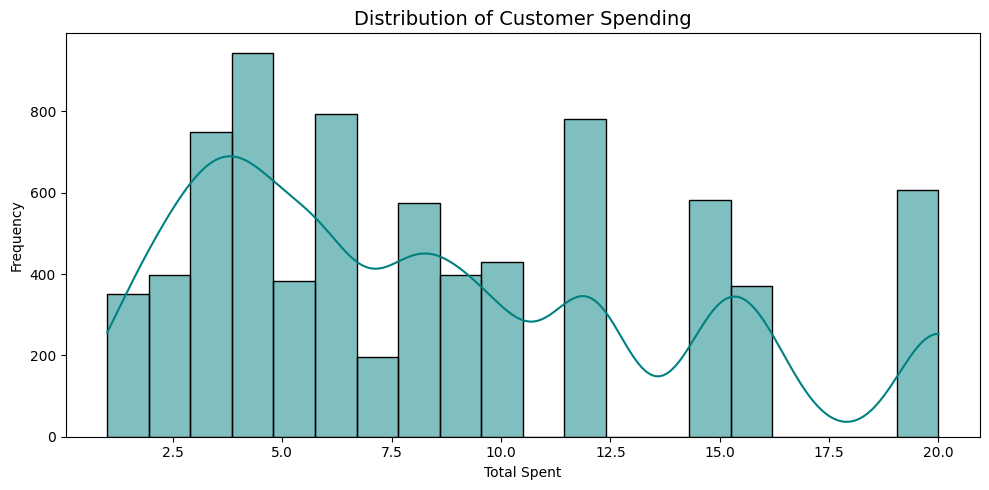

In [ ]:
# distribution histogram sebaran uang customer
plt.figure(figsize=(10, 5))
sns.histplot(df_prep['Total Spent'], kde=True, color='teal', bins=20)
plt.title('Distribution of Customer Spending', fontsize=14)
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

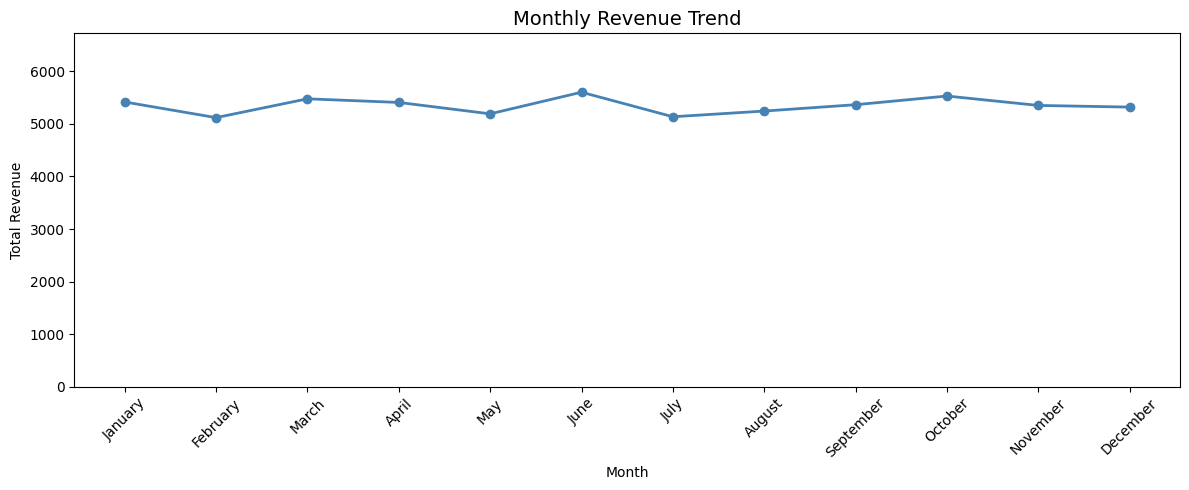

In [ ]:
# menghitung total revenue per bulan
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_revenue = df_prep.groupby('Month')['Total Spent'].sum().reindex(months_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.ylim(0, monthly_revenue.max() * 1.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

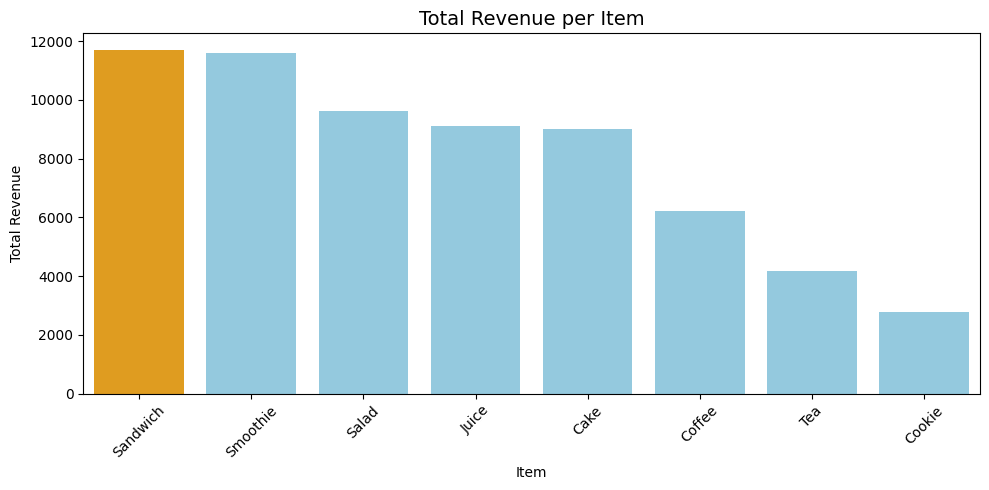

In [ ]:
# menghitung total revenue per item
revenue_per_item = df_prep.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
colors = ['orange' if x == revenue_per_item.max() else 'skyblue' for x in revenue_per_item.values]

plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_per_item.index, y=revenue_per_item.values, palette=colors, hue=revenue_per_item.index, legend=False)
plt.title('Total Revenue per Item', fontsize=14)
plt.xlabel('Item')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

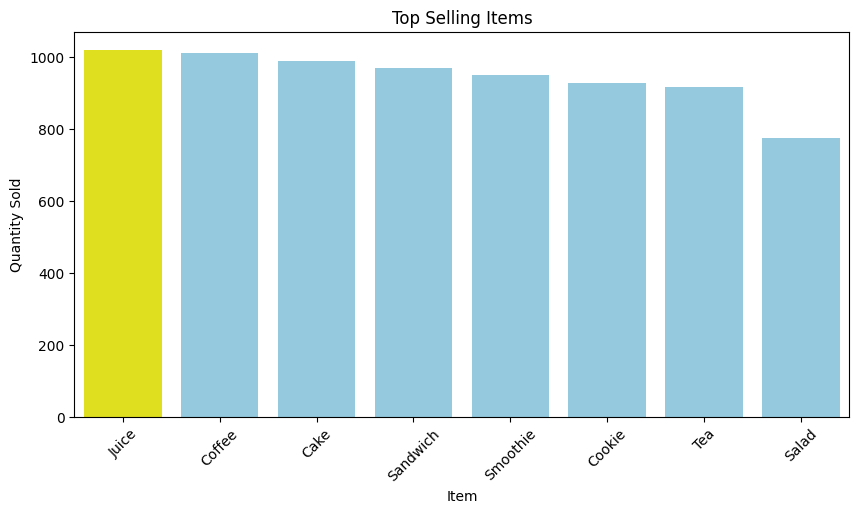

In [ ]:
# Bar Chart, comparisons produk paling laku
plt.figure(figsize=(10, 5))
item_counts = df_prep['Item'].value_counts()
colors = ['yellow' if (x == item_counts.max()) else 'skyblue' for x in item_counts.values]
sns.barplot(x=item_counts.index, y=item_counts.values, palette=colors, hue=item_counts.index, legend=False)
plt.title('Top Selling Items', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Quantity Sold')
plt.show()


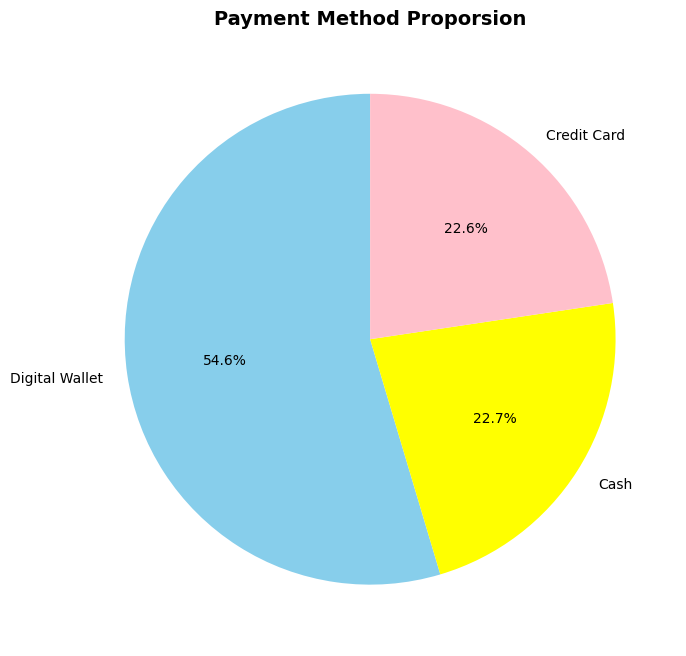

In [ ]:
# membandingkan penggunaan jenis pembayaran

plt.figure(figsize=(7, 7))
day_counts = df_prep['Payment Method'].value_counts()
plt.pie(day_counts, labels = day_counts.index, autopct = '%1.1f%%', colors = ['skyblue', 'yellow','pink'], startangle = 90)
plt.title('Payment Method Proporsion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

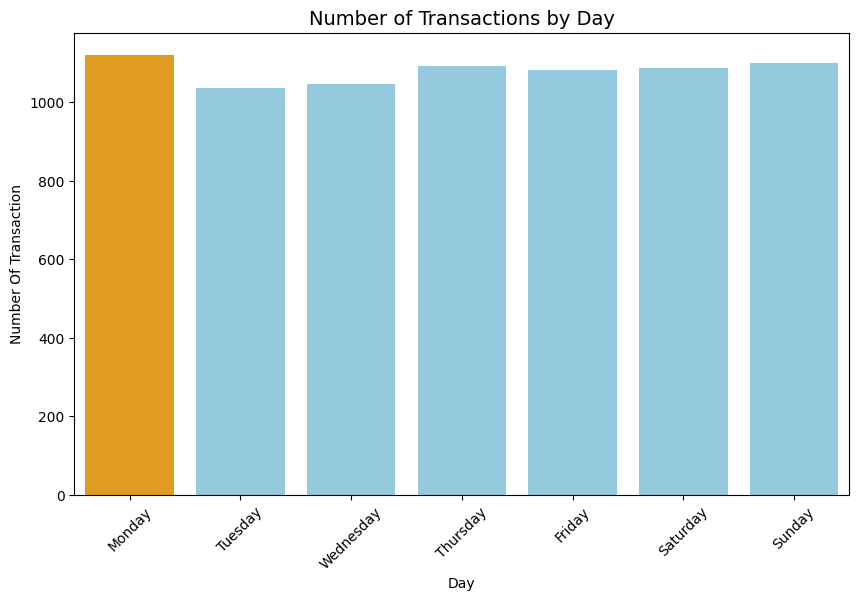

In [ ]:
# menghitung jumlah transaksi per hari
plt.figure(figsize=(10, 6))
day_counts = df_prep['Day Name'].value_counts().reindex(days_order)
colors = ['orange' if (x == day_counts.max()) else 'skyblue' for x in day_counts]
sns.barplot(x=day_counts.index, y=day_counts.values, palette=colors, hue=day_counts.index, legend=False)
plt.title('Number of Transactions by Day', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number Of Transaction')
plt.xticks(rotation=45)
plt.show()

# 5. Advanced Feature Engineering

## a. Product Category Engineering


In [ ]:
# Product Category

df_analysis = df_prep.copy()

beverage_items = ['Coffee', 'Tea', 'Juice', 'Smoothie']
food_items = ['Cake', 'Cookie', 'Sandwich', 'Salad']

df_analysis['Product_Category'] = df_analysis['Item'].apply(
    lambda x: 'Beverage' if x in beverage_items else 'Food'
)

df_analysis['Product_Category'].value_counts()

,count
Product_Category,
Beverage,3901
Food,3661


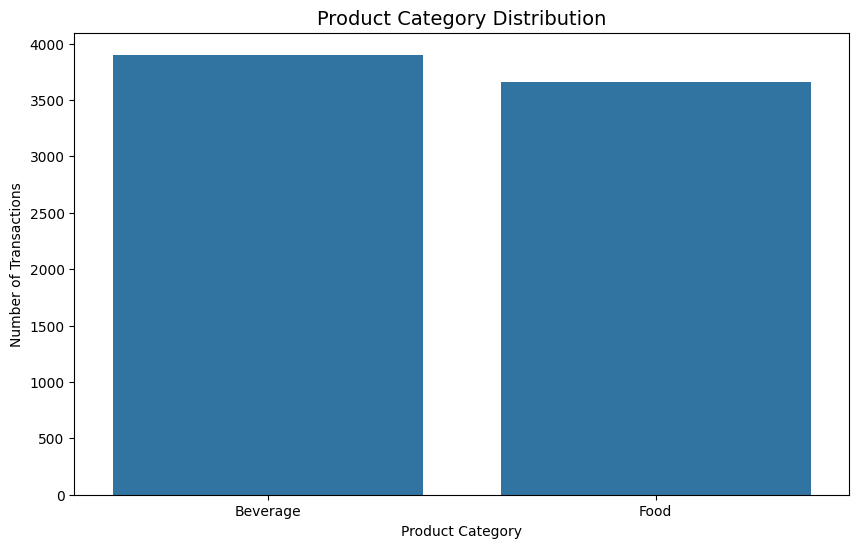

In [ ]:
plt.figure(figsize=(10, 6))

category_counts = df_analysis['Product_Category'].value_counts()

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    legend=False
)

plt.title('Product Category Distribution', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.show()

## b. Purchase Size Engineering

In [ ]:
df_analysis['Purchase_Size'] = pd.cut(
    df_analysis['Quantity'],
    bins=[0,2,4,5],
    labels=['Small','Medium','Large'],
    include_lowest=True
)

df_analysis['Purchase_Size'].value_counts()

,count
Purchase_Size,
Small,3103
Medium,3034
Large,1425


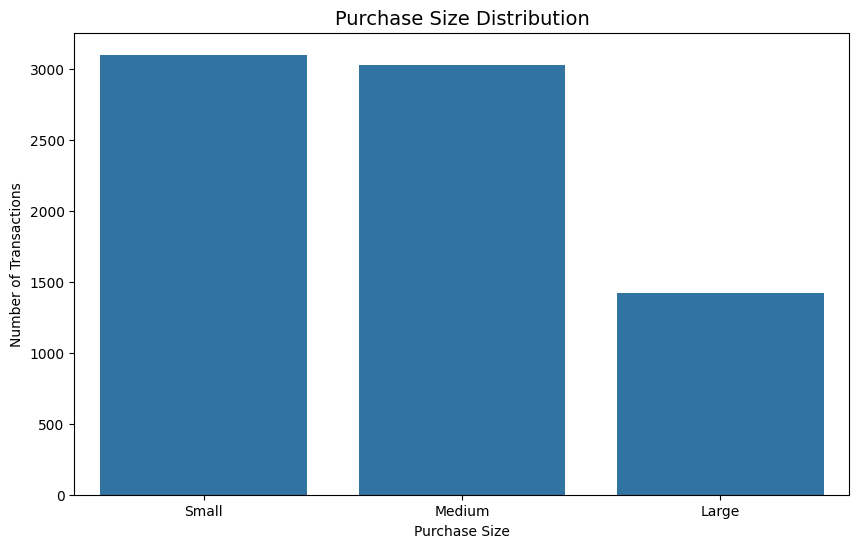

In [ ]:
plt.figure(figsize=(10, 6))

purchase_counts = df_analysis['Purchase_Size'].value_counts().reindex(
    ['Small','Medium','Large']
)

sns.barplot(
    x=purchase_counts.index,
    y=purchase_counts.values,
    legend=False
)

plt.title('Purchase Size Distribution', fontsize=14)
plt.xlabel('Purchase Size')
plt.ylabel('Number of Transactions')
plt.show()

## c. Spending Level Engineering

In [ ]:
q25 = df_analysis['Total Spent'].quantile(0.25)
q50 = df_analysis['Total Spent'].quantile(0.50)
q75 = df_analysis['Total Spent'].quantile(0.75)

df_analysis['Spending_Level'] = pd.cut(
    df_analysis['Total Spent'],
    bins=[0,q25,q50,q75,float('inf')],
    labels=['Budget','Standard','Premium','Luxury'],
    include_lowest=True
)

df_analysis['Spending_Level'].value_counts()

,count
Spending_Level,
Budget,2258
Premium,2186
Luxury,1560
Standard,1558


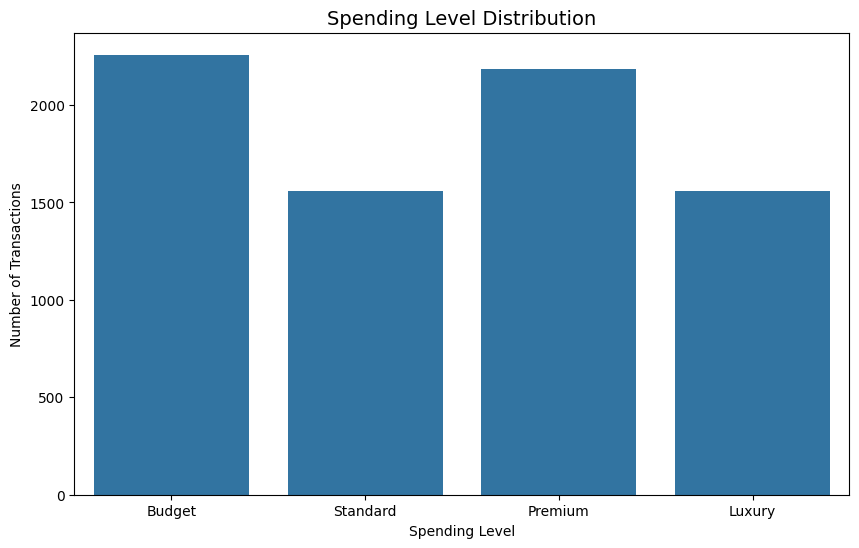

In [ ]:
plt.figure(figsize=(10, 6))

spending_counts = df_analysis['Spending_Level'].value_counts().reindex(
    ['Budget','Standard','Premium','Luxury']
)

sns.barplot(
    x=spending_counts.index,
    y=spending_counts.values,
    legend=False
)

plt.title('Spending Level Distribution', fontsize=14)
plt.xlabel('Spending Level')
plt.ylabel('Number of Transactions')
plt.show()

## Exporting Engineered Dataset


In [ ]:
# Check kolom yang baru ditambahkan kedalam dataset
df_analysis.head(25)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day Type,Day Name,Order Status,Product_Category,Purchase_Size,Spending_Level
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,September,Weekday,Friday,To-Go,Beverage,Small,Budget
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,May,Weekday,Tuesday,In-store,Food,Medium,Premium
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,July,Weekday,Wednesday,In-store,Food,Medium,Budget
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27,April,Weekday,Thursday,In-store,Food,Small,Premium
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,June,Weekend,Sunday,In-store,Beverage,Small,Budget
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,In-store,2023-03-31,March,Weekday,Friday,In-store,Beverage,Large,Luxury
6,TXN_6699534,Sandwich,4,4.0,16.0,Cash,In-store,2023-10-28,October,Weekend,Saturday,In-store,Food,Medium,Luxury
7,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31,December,Weekend,Sunday,In-store,Food,Large,Luxury
8,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03,May,Weekday,Wednesday,In-store,Food,Small,Premium
9,TXN_9437049,Cookie,5,1.0,5.0,Digital Wallet,Takeaway,2023-06-01,June,Weekday,Thursday,To-Go,Food,Large,Standard


In [ ]:
# melihat struktur dan tipe data yang di feature engineer
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7562 entries, 0 to 7561
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7562 non-null   object        
 1   Item              7562 non-null   object        
 2   Quantity          7562 non-null   int64         
 3   Price Per Unit    7562 non-null   float64       
 4   Total Spent       7562 non-null   float64       
 5   Payment Method    7562 non-null   object        
 6   Location          7562 non-null   object        
 7   Transaction Date  7562 non-null   datetime64[ns]
 8   Month             7562 non-null   object        
 9   Day Type          7562 non-null   object        
 10  Day Name          7562 non-null   category      
 11  Order Status      7562 non-null   object        
 12  Product_Category  7562 non-null   object        
 13  Purchase_Size     7562 non-null   category      
 14  Spending_Level    7562 n

In [ ]:
# melihat hasil statistiknya
df_prep.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,7562.0,2.968791,1.0,2.0,3.0,4.0,5.0,1.400429
Price Per Unit,7562.0,2.896985,1.0,2.0,3.0,4.0,5.0,1.245505
Total Spent,7562.0,8.487702,1.0,4.0,7.5,12.0,20.0,5.428697
Transaction Date,7562,2023-07-01 22:07:04.649563648,2023-01-01 00:00:00,2023-04-01 00:00:00,2023-07-02 00:00:00,2023-10-02 00:00:00,2023-12-31 00:00:00,NaN


In [ ]:
# export data yang sudah ditambahkan kolom feature engineernya
df_analysis.to_csv(
    'cafe_sales_analysis.csv',
    index=False
)

# 6.Relationship Analysis

6.1 Product Category vs Order Status

In [ ]:
#Crosstab
category_status = pd.crosstab(
    df_analysis['Product_Category'],
    df_analysis['Location']
)

category_status

Location,In-store,Takeaway
Product_Category,,
Beverage,2768,1133
Food,2533,1128


In [ ]:
#Presentase
category_status_pct = pd.crosstab(
    df_analysis['Product_Category'],
    df_analysis['Location'],
    normalize='index'
) * 100

category_status_pct.round(2)

Location,In-store,Takeaway
Product_Category,,
Beverage,70.96,29.04
Food,69.19,30.81


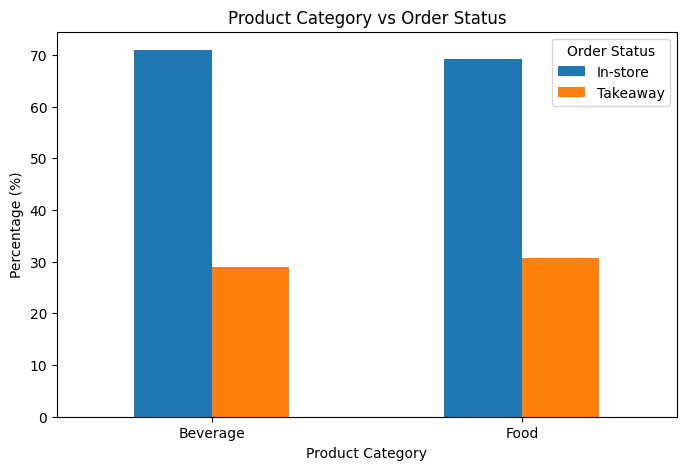

In [ ]:
#Visualisasi
category_status_pct.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Product Category vs Order Status')
plt.xlabel('Product Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Order Status')
plt.show()

6.2 Product Category vs Payment Method

In [ ]:
#Crosstab
category_payment = pd.crosstab(
    df_analysis['Product_Category'],
    df_analysis['Payment Method']
)

category_payment

Payment Method,Cash,Credit Card,Digital Wallet
Product_Category,,,
Beverage,852,858,2191
Food,868,854,1939


In [ ]:
#Persentase
category_payment_pct = pd.crosstab(
    df_analysis['Product_Category'],
    df_analysis['Payment Method'],
    normalize='index'
) * 100

category_payment_pct.round(2)

Payment Method,Cash,Credit Card,Digital Wallet
Product_Category,,,
Beverage,21.84,21.99,56.17
Food,23.71,23.33,52.96


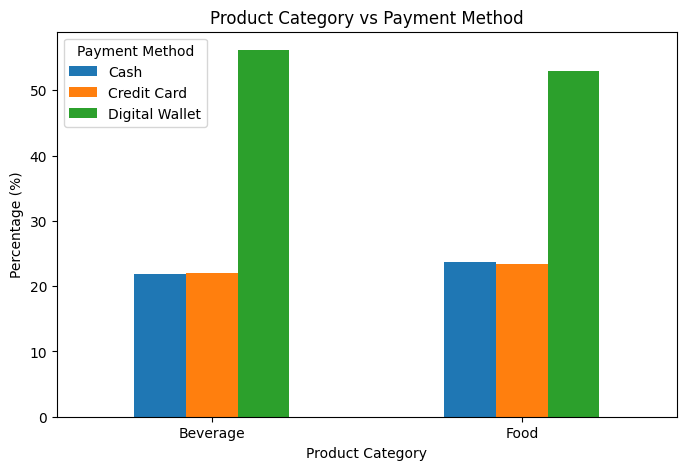

In [ ]:
#Visualisasi
category_payment_pct.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Product Category vs Payment Method')
plt.xlabel('Product Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Payment Method')
plt.show()

6.3 Weekday vs Weekend Analysis

In [ ]:
#Membuat ketgori hari
df_analysis['Transaction Date'] = pd.to_datetime(
    df_analysis['Transaction Date']
)

df_analysis['Day_Type'] = np.where(
    df_analysis['Transaction Date'].dt.dayofweek >= 5,
    'Weekend',
    'Weekday'
)

In [ ]:
#Crosstab Product Category vs Day Type
weekday_weekend = pd.crosstab(
    df_analysis['Day_Type'],
    df_analysis['Product_Category']
)

weekday_weekend

Product_Category,Beverage,Food
Day_Type,,
Weekday,2794,2581
Weekend,1107,1080


In [ ]:
#Persentase
weekday_weekend_pct = pd.crosstab(
    df_analysis['Day_Type'],
    df_analysis['Product_Category'],
    normalize='index'
) * 100

weekday_weekend_pct.round(2)

Product_Category,Beverage,Food
Day_Type,,
Weekday,51.98,48.02
Weekend,50.62,49.38


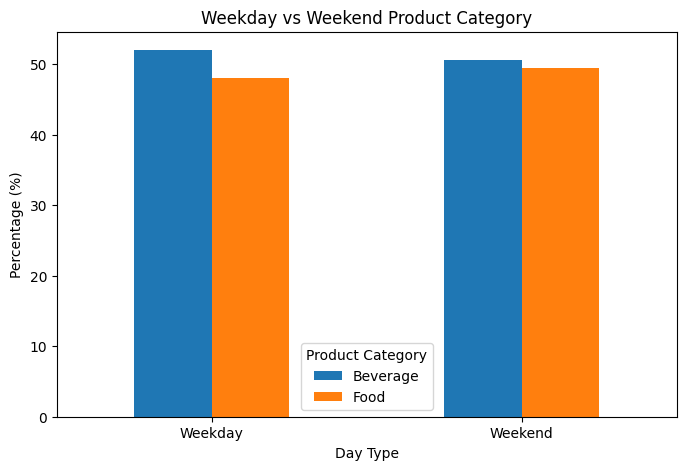

In [ ]:
#Visualisasi
weekday_weekend_pct.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Weekday vs Weekend Product Category')
plt.xlabel('Day Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.show()

6.4 Purchase Size vs Order Status

In [ ]:
def get_purchase_size(qty):
    if qty <= 2:
        return 'Small Basket'
    elif qty <= 4:
        return 'Medium Basket'
    else:
        return 'Large Basket'

df_prep['Purchase Size'] = df_prep['Quantity'].apply(get_purchase_size)

In [ ]:
def get_spending_level(spent):
    if spent <= 5.0:
        return 'Budget'
    elif spent <= 10.0:
        return 'Standard'
    elif spent <= 15.0:
        return 'Premium'
    else:
        return 'Luxury'

df_prep['Spending Level'] = df_prep['Total Spent'].apply(get_spending_level)

In [ ]:
def get_product_category(item):
    beverages = ['Coffee', 'Smoothie', 'Juice', 'Tea']
    if item in beverages:
        return 'Beverage'
    else:
        return 'Food'

df_prep['Product Category'] = df_prep['Item'].apply(get_product_category)

print("Kolom 'Purchase Size', 'Spending Level', dan 'Product Category' BERHASIL DIBUAT!")

Kolom 'Purchase Size', 'Spending Level', dan 'Product Category' BERHASIL DIBUAT!


In [ ]:
# # Crosstab
crosstab_63 = pd.crosstab(df_prep['Purchase Size'], df_prep['Order Status'])
print("\n[Crosstab Frequencies]")
print(crosstab_63)


[Crosstab Frequencies]
Order Status   In-store  To-Go
Purchase Size                 
Large Basket       1003    422
Medium Basket      2135    899
Small Basket       2163    940


In [ ]:
# presentase proporsi perbaris/purchaase size
percentage_63 = pd.crosstab(df_prep['Purchase Size'], df_prep['Order Status'], normalize='index') * 100
print("\n[Persentase Kontingensi (%)]")
print(percentage_63.round(2))


[Persentase Kontingensi (%)]
Order Status   In-store  To-Go
Purchase Size                 
Large Basket      70.39  29.61
Medium Basket     70.37  29.63
Small Basket      69.71  30.29


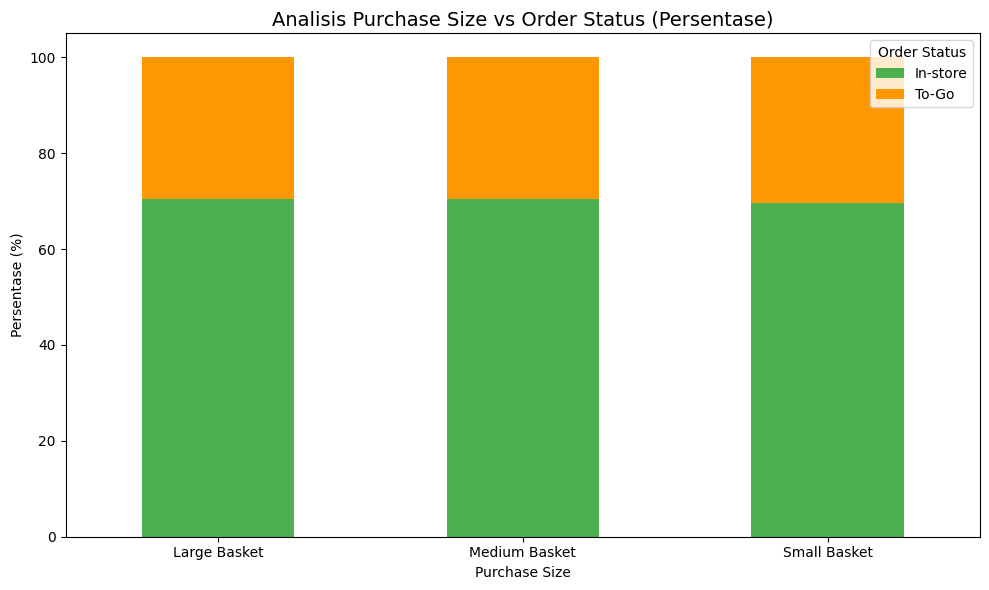

In [ ]:
# Visualisasi
plt.figure(figsize=(10, 6))
percentage_63.plot(kind='bar', stacked=True, color=['#4caf50', '#ff9800'], ax=plt.gca())
plt.title('Analisis Purchase Size vs Order Status (Persentase)', fontsize=14)
plt.xlabel('Purchase Size')
plt.ylabel('Persentase (%)')
plt.legend(title='Order Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

6.5 Spending Level vs Product Category

In [ ]:
# Crosstab
crosstab_65 = pd.crosstab(df_prep['Spending Level'], df_prep['Product Category'])
print("\n[Crosstab Frekuensi]")
print(crosstab_65)


[Crosstab Frekuensi]
Product Category  Beverage  Food
Spending Level                  
Budget                1316  1510
Luxury                 391   587
Premium                588   776
Standard              1606   788


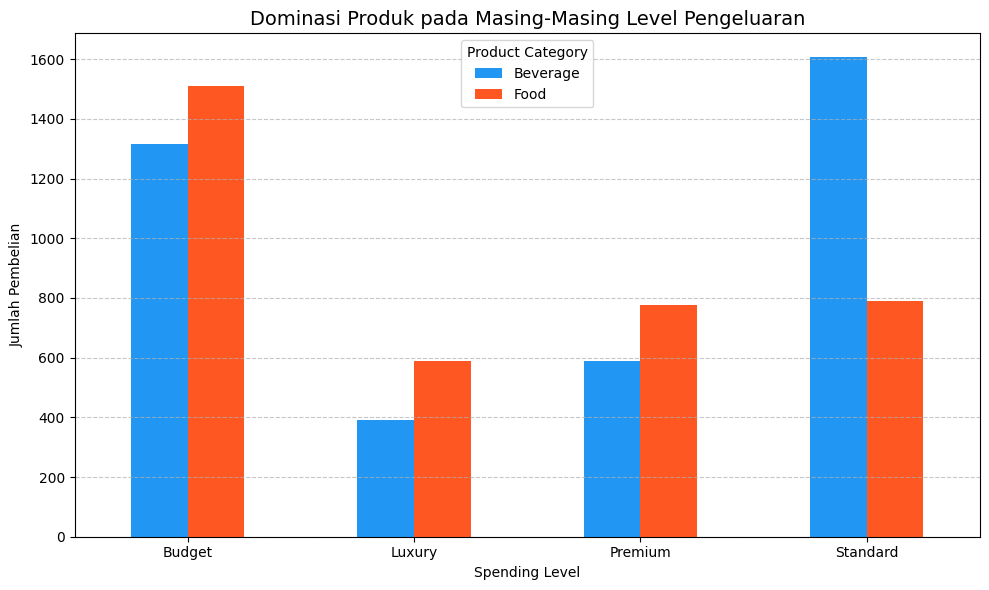

In [ ]:
# Visualisasi
plt.figure(figsize=(10, 6))
crosstab_65.plot(kind='bar', color=['#2196f3', '#ff5722'], ax=plt.gca())
plt.title('Dominasi Produk pada Masing-Masing Level Pengeluaran', fontsize=14)
plt.xlabel('Spending Level')
plt.ylabel('Jumlah Pembelian')
plt.legend(title='Product Category')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

6.6 Revenue Contribution Analysis

In [ ]:
# kontribusi berdasarkan product category

rev_product = df_prep.groupby('Product Category')['Total Spent'].sum().reset_index()
total_rev = rev_product['Total Spent'].sum()
rev_product['Percentage (%)'] = (rev_product['Total Spent'] / total_rev) * 100

print("--- Kontribusi Revenue per Kategori Produk ---")
print(rev_product.round(2))

--- Kontribusi Revenue per Kategori Produk ---
  Product Category  Total Spent  Percentage (%)
0         Beverage      31105.0           48.46
1             Food      33079.0           51.54


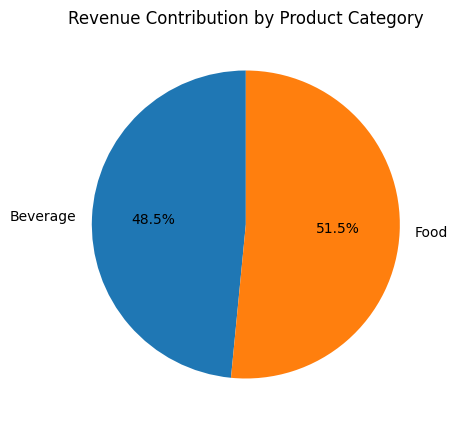

In [ ]:
# Pie Chart Product Category
plt.figure(figsize=(5,5))
plt.pie(rev_product['Total Spent'], labels=rev_product['Product Category'], autopct='%1.1f%%', startangle=90)
plt.title('Revenue Contribution by Product Category')
plt.show()

In [ ]:
# Kontribusi berdasarkan Purchase Size
rev_size = df_prep.groupby('Purchase Size')['Total Spent'].sum().reset_index()
rev_size['Percentage (%)'] = (rev_size['Total Spent'] / total_rev) * 100

print("\n--- Kontribusi Revenue per Ukuran Pembelian ---")
print(rev_size.round(2))


--- Kontribusi Revenue per Ukuran Pembelian ---
   Purchase Size  Total Spent  Percentage (%)
0   Large Basket      18965.0           29.55
1  Medium Basket      31385.0           48.90
2   Small Basket      13834.0           21.55


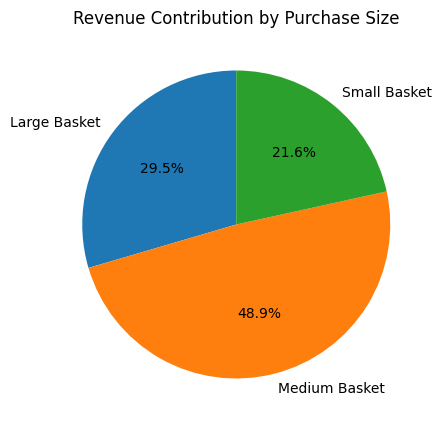

In [ ]:
# Pie Chart purchase Size
plt.figure(figsize=(5,5))
plt.pie(rev_size['Total Spent'], labels=rev_size['Purchase Size'], autopct='%1.1f%%', startangle=90)
plt.title('Revenue Contribution by Purchase Size')
plt.show()

In [ ]:
# Kontribusi berdasarkan spending level
rev_spending = df_prep.groupby('Spending Level')['Total Spent'].sum().reset_index()
rev_spending['Percentage (%)'] = (rev_spending['Total Spent'] / total_rev) * 100

print("\n--- Kontribusi Revenue per Level Pengeluaran ---")
print(rev_spending.round(2))


--- Kontribusi Revenue per Level Pengeluaran ---
  Spending Level  Total Spent  Percentage (%)
0         Budget       9263.0           14.43
1         Luxury      18080.0           28.17
2        Premium      18114.0           28.22
3       Standard      18727.0           29.18


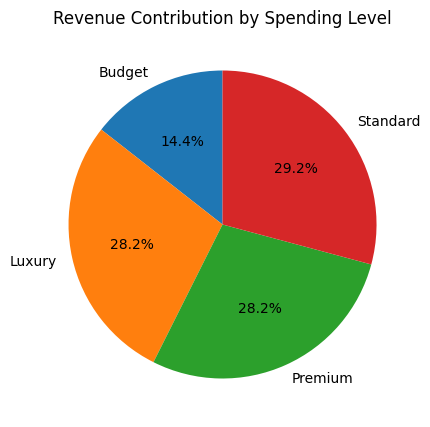

In [ ]:
# Pie Chart Spending Level
plt.figure(figsize=(5,5))
plt.pie(rev_spending['Total Spent'], labels=rev_spending['Spending Level'], autopct='%1.1f%%', startangle=90)
plt.title('Revenue Contribution by Spending Level')
plt.show()

# 7.Evaluation

7.1 Code Evaluation

In [ ]:
# Cek Distribusi kolom kolom baru
target_cols = ['Product Category', 'Purchase Size', 'Spending Level']
for col in target_cols:
    counts = df_prep[col].value_counts()
    pct = df_prep[col].value_counts(normalize=True) * 100

    df_eval = pd.DataFrame({
        'Jumlah (Freq)': counts,
        'Persentase (%)': pct
    })
    print(f"\nDistribusi untuk kolom: {col}")
    print(df_eval.round(2))


Distribusi untuk kolom: Product Category
                  Jumlah (Freq)  Persentase (%)
Product Category                               
Beverage                   3901           51.59
Food                       3661           48.41

Distribusi untuk kolom: Purchase Size
               Jumlah (Freq)  Persentase (%)
Purchase Size                               
Small Basket            3103           41.03
Medium Basket           3034           40.12
Large Basket            1425           18.84

Distribusi untuk kolom: Spending Level
                Jumlah (Freq)  Persentase (%)
Spending Level                               
Budget                   2826           37.37
Standard                 2394           31.66
Premium                  1364           18.04
Luxury                    978           12.93


7.2 Markdown Evaluation

berdasarkan hasil dari code evaluation di atas dan setelah melakukan tahap feature engineering untuk membentuk matrix segmentasi baru seperti **Product Category, Purchase Size dan Spending Level**.

ini adalah hasil evaluasi distribusi data kami beserta analisa mendalam tentang karakteristik operasional dan profile pelanggan kafe saat ini.

1. Kategori Produk
- **Beverage** berjumlah **3.901** transaksi dengan presentase **51.59%**
- **Food** berjumlah **3.661** transaksi dengan presentase **48.41%**
---
2. Purchase Size
- **Small basket** berjumlah **3.103** transaksi deengan presentase **41.03%**
- **Medium Basket** berjumlah **3.034** transaksi dengan presentase **40.12%**
- **Large Basket** berjumlah **1.425** transaksi dengan presentase **18.84%**

---

3. Spending level
- **Budget** nerjumlah **2.826** transaksi dengan presentase **37.37%**
- **Standart** berjumlah **2.394** transaksi dengan presentase **31.66%**
- **Premium** berjumlah **1.364** transaksi dengan preseentase **18.04%**
- **Luxury** berjumlah **976** transaksi dengan presentase **12.93%**


**Analisis Evaluaasi**

1. **Karakteristik dari product category**
menurut data, menunjukan kalau perputaran penjualaaan antara makanan dan minuman di kafe berjalan **sangat seimbang**. Kelompok Beverage dan Food hanya memiliki perbandingan sekitar **3.18%**

- insight : Distribusi yang terlihat 50:50 ini membuktikan kalau konsumen tidak hanya menjadikan kafe ini hanya sebagai tempat nongkrong dan minum, tapi juga seebagai destinasi untuk makan. supply chain untuk kedua kategori ini harus di jaga dengan seimbang deengan tingkat kebutuhan yang di sama ratakaan tingginyaa agar tidak terjadi kehilangan potensi penjualan / kehabisan stock.

---
2. **Pola Purchase Size**
Data Volume dari purchase Size menunjukan bahwa adanya pola yang sangat terkonsentrasi. sekitar **81.15%** total transaksi didominasi oleh kombinasi antara small basket dan medium basket. ini menunjukan adanya ketimpangan yang sangat signifikan yang di dapati jika kita melihat Large basket yang hanya menyumbang 18.84%
- insight : karakteristik pengunjung ini bersifat individual dan kelompok kecil (2-3) orang. kafe jarang menerima order masal dalam satu struk. strategi penataan meja sebaiknya dioptimalkan dari kapasitaas meja yang kecil, dan tim pemasaran harus ngerancang paket bundling agar mendorong pelanggan untuk dari yg hanya membeli 1-2 iteem menjadi 3-4 item per transaksi
---
3. **Segmentasi pasar dari Spending Level**
Bisa kita lihat dari sisi finansial kalau rata rata pelanggan kafe ini sangat sensitif terhadap harga, segmen** budget dan standart** menguasai hampir **70%** dari keseluruhan profile konsumen. sedangkan kelompok **premium dan luxury** kalau di gabungkan hanya menyentuh angka **31%**

- insight : Core customer kafe ini adalah pemburu value for money. sebaiknya jangan sampai membuat kebijakan kenaikan harga menu dengan agresif karena sangat beresiko mematikan volume transaksi. fokus utama manajemen adalah harus bergantung pada strategi kuantitas yang tinggi dengan margin rendah / high volume, low margin pada meenu regulr untuk menjaga loyalitas dari pelanggan.


# 8. Business Recomendation

**Recomendation 1 :**  Meeeengoptimalkan Kontributor Revenue Terbesar
melihat Beverage deengan preseentase 51.59% adalah merupakan kontributor transaksi terbeeesar dan utama, kafeee sebaiknya meluncurkan program promosi khusus pada kategori ini.

**Reecomendation 2 :** Diferensiasi Strategi pmasaran
ada perbedaan yg signifikan dari seegmen budget dan prmium dan memerlukan pendekatan yang berbeda beda.
- Budget : fokuskan pada strateegi value for money. andalkan promo "menu hemat" atau misalnya "beli 2 leebih murah" untuk menjaga volume transaksi dari basis pelanggan yg meendominasi ini

- Premium Customer : Fokuskan pada aspek eksklusifitas dan kualitas. tawarkan menu musiman/limiteed edition untuk memaksimalkan margin keuntungan di segmen ini

**Recomendation 3 :** Penyesuaian Layanan
Data menunjukan kalau 81.15% transaksi adalah small dan medium basket. penyesuaian layanan yang bisa dilakukan aadalah :

- fast Checkout untuk small : kafe menyediakan jalur traansaksi yang cepat bagi konsumen yg hanya membeli 1-2 item untuk meningkatkan perputaaran meja
- bundle promotion : dari yg di lihat pada segmen large basket yg ganya 18.84%, berikan pelayanan yg insentif seperti family packet atau diskon khusus untuk pembelian di atas 5 utem untuk mendorong konsumen beralih ke volume belanja yg lebih besar.